# Final Cervical Cancer Risk-Factor Modeling Project

This consolidated notebook preserves the original project's useful exploration while applying the reviewed, leakage-aware modeling workflow. Run top-to-bottom for a reproducible result.

> **Educational use only:** this work is not clinically validated and must not be used for diagnosis or medical decisions.

## What was preserved and what was improved

The original notebook's raw-data preview, dataset summary, missingness inspection, correlation study, distributions, and XGBoost experiment are retained in this final version. Duplicate installation cells and unsafe steps were removed. In particular, preprocessing is now fitted inside pipelines, the split is stratified, diagnostic leakage features are excluded, and evaluation reports class-sensitive metrics rather than accuracy alone.

## 1. Imports and display configuration

We use pandas for tabular analysis, NumPy for numerical operations, and
seaborn/matplotlib for plots. A fixed visual theme keeps figures consistent in
the notebook and in the project documentation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

# Resolve paths from either the project directory or its parent repository.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data" / "cervical_cancer.csv").exists():
    PROJECT_DIR = PROJECT_DIR / "001_Cervical_Cancer_Predection_with_ML"

DATA_PATH = PROJECT_DIR / "data" / "cervical_cancer.csv"
ASSET_DIR = PROJECT_DIR / "docs" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATA_PATH.resolve()}")

Dataset: D:\Ck\Programming\github\machine-learning-projects\001_Cervical_Cancer_Predection_with_ML\data\cervical_cancer.csv


## 2. Load the raw dataset

Values are loaded as provided so we can inspect the source representation before
cleaning it. In this dataset, a question mark (`?`) means “not recorded”; pandas
does not recognize that token as missing unless we tell it to.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}")
raw.head()

Rows: 858 | Columns: 36


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0


## 3. Define the prediction target and leakage boundary

`Biopsy` is the binary outcome: `1` means a positive biopsy result and `0` means
a negative result. Other screening and diagnosis outcomes are excluded from the
eventual predictor because they happen at roughly the same clinical stage—or
later—and could reveal the answer rather than represent an earlier risk factor.

In [3]:
TARGET = "Biopsy"
LEAKAGE_COLUMNS = [
    "Hinselmann", "Schiller", "Citology",
    "Dx:Cancer", "Dx:CIN", "Dx:HPV", "Dx",
]

print("Target:", TARGET)
print("Excluded from risk-factor modeling:", ", ".join(LEAKAGE_COLUMNS))

Target: Biopsy
Excluded from risk-factor modeling: Hinselmann, Schiller, Citology, Dx:Cancer, Dx:CIN, Dx:HPV, Dx


## 4. Convert the missing-value marker and numeric columns

Every feature is conceptually numeric, but the `?` marker causes pandas to store
many columns as generic objects. Replacing `?` with `NaN` and coercing values to
numbers enables valid summaries, correlations, imputers, and models. Coercion is
intentionally explicit: unexpected text becomes missing instead of silently
participating in calculations.

In [4]:
data = raw.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")

quality_summary = pd.DataFrame(
    {
        "dtype_before": raw.dtypes.astype(str),
        "dtype_after": data.dtypes.astype(str),
        "missing_count": data.isna().sum(),
        "missing_percent": data.isna().mean().mul(100).round(2),
        "unique_values": data.nunique(dropna=True),
    }
).sort_values("missing_percent", ascending=False)

quality_summary.head(12)

,dtype_before,dtype_after,missing_count,missing_percent,unique_values
STDs: Time since last diagnosis,object,float64,787,91.72,18
STDs: Time since first diagnosis,object,float64,787,91.72,18
IUD,object,float64,117,13.64,2
IUD (years),object,float64,117,13.64,26
Hormonal Contraceptives,object,float64,108,12.59,2
Hormonal Contraceptives (years),object,float64,108,12.59,40
STDs:pelvic inflammatory disease,object,float64,105,12.24,2
STDs:vulvo-perineal condylomatosis,object,float64,105,12.24,2
STDs:HPV,object,float64,105,12.24,2
STDs:Hepatitis B,object,float64,105,12.24,2


## 5. Validate basic data integrity

These checks catch accidental dataset replacement, duplicate rows, invalid target
labels, and impossible ages early. Assertions are useful because a notebook that
merely runs is not necessarily analyzing the intended data.

In [5]:
assert TARGET in data.columns, "The expected target column is missing."
assert set(data[TARGET].dropna().unique()).issubset({0, 1}), "Target must be binary."
assert data["Age"].between(0, 120).all(), "Age contains an implausible value."

print(f"Duplicate rows: {data.duplicated().sum():,}")
print(f"Completely empty columns: {data.isna().all().sum():,}")
print(f"Target missing values: {data[TARGET].isna().sum():,}")

Duplicate rows: 23
Completely empty columns: 0
Target missing values: 0


## 6. Missing-data profile

Missingness matters because deleting incomplete rows can disproportionately remove
certain patient groups and shrink an already small positive class. We visualize
the most incomplete variables and later use median imputation fitted only on the
training data.

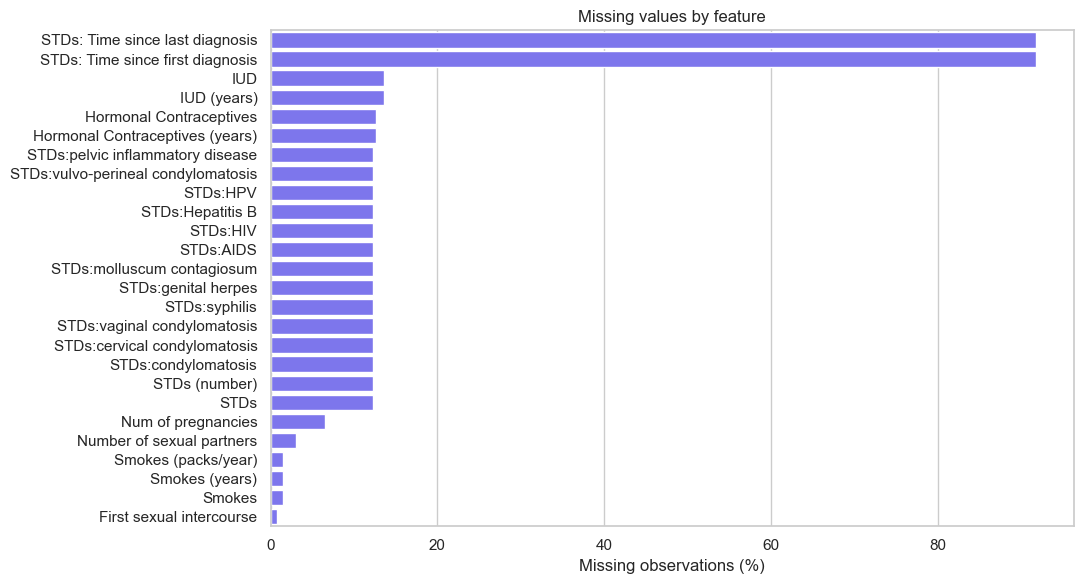

In [6]:
missing = data.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=missing.values, y=missing.index, color="#6C63FF", ax=ax)
ax.set(title="Missing values by feature", xlabel="Missing observations (%)", ylabel="")
fig.tight_layout()
fig.savefig(ASSET_DIR / "missing_values.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Target balance

Medical-event datasets are often imbalanced. Accuracy can therefore be misleading:
a model predicting only the majority class may appear accurate while detecting no
positive cases. This distribution determines our stratified split, class weighting,
and emphasis on recall and precision–recall AUC.

,count,percent
Biopsy,,
0,803,93.59
1,55,6.41


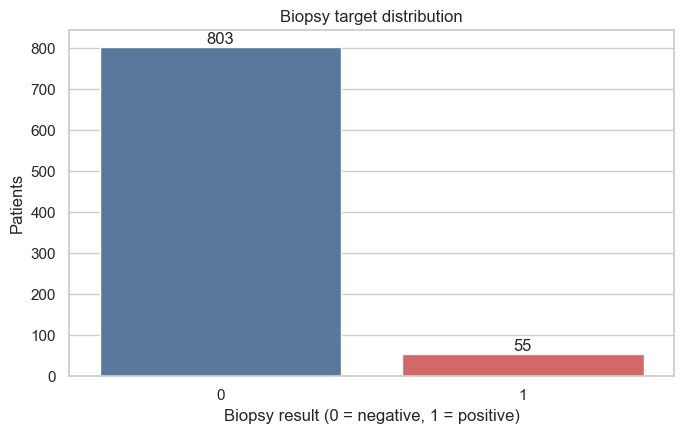

In [7]:
target_counts = data[TARGET].value_counts().sort_index()
target_percent = data[TARGET].value_counts(normalize=True).sort_index().mul(100)
display(pd.DataFrame({"count": target_counts, "percent": target_percent.round(2)}))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=data, x=TARGET, hue=TARGET, palette=["#4C78A8", "#E45756"], legend=False, ax=ax)
ax.set(title="Biopsy target distribution", xlabel="Biopsy result (0 = negative, 1 = positive)", ylabel="Patients")
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(ASSET_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Patient age distribution

Age is inspected both overall and by biopsy outcome. This reveals the population
represented by the dataset and whether a simple demographic shift is visible.
The plot is descriptive only; overlapping distributions do not prove that age is
irrelevant once other factors are considered.

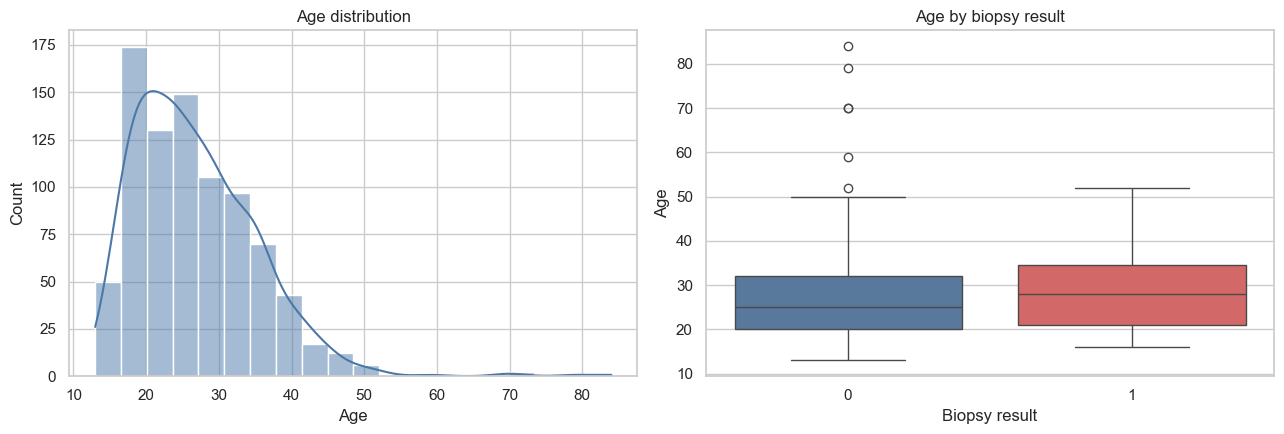

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=data, x="Age", bins=20, kde=True, color="#4C78A8", ax=axes[0])
axes[0].set_title("Age distribution")
sns.boxplot(data=data, x=TARGET, y="Age", hue=TARGET, palette=["#4C78A8", "#E45756"], legend=False, ax=axes[1])
axes[1].set_title("Age by biopsy result")
axes[1].set_xlabel("Biopsy result")
fig.tight_layout()
fig.savefig(ASSET_DIR / "age_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Selected behavioral and reproductive factors

We compare interpretable, pre-diagnostic variables rather than every column at
once. Median values are shown because several measures are skewed and contain
outliers. These summaries identify hypotheses; they do not establish causation.

In [9]:
selected_features = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes (years)",
    "Hormonal Contraceptives (years)",
    "IUD (years)",
    "STDs (number)",
]

group_summary = data.groupby(TARGET)[selected_features].median().T
group_summary.columns = ["Biopsy negative (median)", "Biopsy positive (median)"]
group_summary

,Biopsy negative (median),Biopsy positive (median)
Age,25.0,28.0
Number of sexual partners,2.0,2.0
First sexual intercourse,17.0,17.0
Num of pregnancies,2.0,2.5
Smokes (years),0.0,0.0
Hormonal Contraceptives (years),0.5,0.5
IUD (years),0.0,0.0
STDs (number),0.0,0.0


## 10. Correlation overview for risk-factor features

Correlation can reveal redundant variables and broad linear relationships. We
exclude diagnostic leakage fields and constant columns. Correlation is not
causation, and low linear correlation does not rule out a nonlinear association.

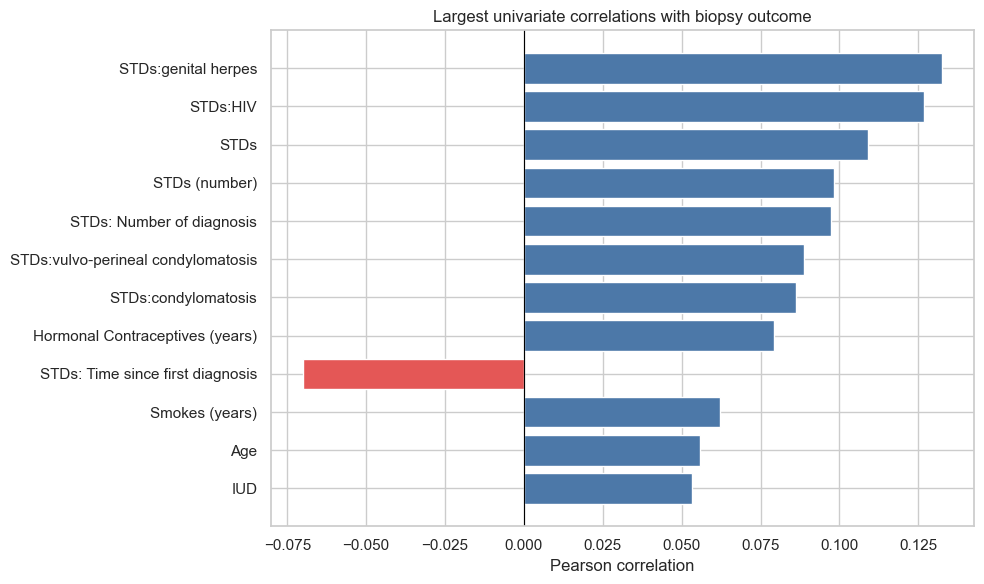

In [10]:
risk_features = [c for c in data.columns if c not in [TARGET, *LEAKAGE_COLUMNS]]
correlation_data = data[risk_features + [TARGET]].dropna(axis=1, how="all")
target_correlations = (
    correlation_data.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E45756" if value < 0 else "#4C78A8" for value in target_correlations.values]
ax.barh(target_correlations.index[::-1], target_correlations.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Largest univariate correlations with biopsy outcome", xlabel="Pearson correlation", ylabel="")
fig.tight_layout()
fig.savefig(ASSET_DIR / "target_correlations.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. EDA conclusions and modeling decisions

The analysis leads to the following decisions:

1. Replace `?` with missing values and impute inside a model pipeline.
2. Keep every row; dropping incomplete records would waste data and may add bias.
3. Use `Biopsy` as the target and remove contemporaneous diagnosis fields.
4. Use a stratified train/test split because positive biopsies are uncommon.
5. Compare a transparent logistic-regression baseline with a nonlinear random forest.
6. Prioritize recall, precision, F1, ROC-AUC, and PR-AUC over raw accuracy.
7. Treat all results as educational evidence, not clinical validation.

In [11]:
eda_summary = {
    "rows": int(data.shape[0]),
    "columns": int(data.shape[1]),
    "positive_biopsies": int(data[TARGET].sum()),
    "positive_rate_percent": round(float(data[TARGET].mean() * 100), 2),
    "columns_with_missing_values": int((data.isna().sum() > 0).sum()),
    "duplicate_rows": int(data.duplicated().sum()),
}
eda_summary

{'rows': 858,
 'columns': 36,
 'positive_biopsies': 55,
 'positive_rate_percent': 6.41,
 'columns_with_missing_values': 26,
 'duplicate_rows': 23}

## Original exploration views, retained in a clearer form

These cells preserve the original notebook's most useful inspection steps. They use the cleaned `data` table so they are consistent with the modern workflow, and the figures are sized for readability.

In [12]:
# Original raw-data inspection, retained for quick orientation.
raw.tail(20)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
838,35,3.0,18.0,3.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
839,31,3.0,19.0,1.0,0.0,0.0,0.0,1.0,0.08,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,1,0,0,1,0,0,0,0
840,24,2.0,16.0,3.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
841,23,2.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
842,36,3.0,16.0,3.0,1.0,6.0,0.3,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
843,30,3.0,14.0,3.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
844,26,8.0,15.0,1.0,1.0,9.0,1.35,1.0,5.0,1.0,0.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
845,19,2.0,15.0,2.0,0.0,0.0,0.0,1.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
846,35,2.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
847,30,3.0,22.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0


In [13]:
# Original schema and summary checks, retained before modeling.
data.info()
display(data.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.820513,8.497948,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.527644,1.667760,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995300,2.803355,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.275561,1.447414,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.145562,0.352876,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.219721,4.089017,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453144,2.226610,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.641333,0.479929,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.256419,3.764254,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.112011,0.315593,0.0,0.0,0.0,0.0,1.0


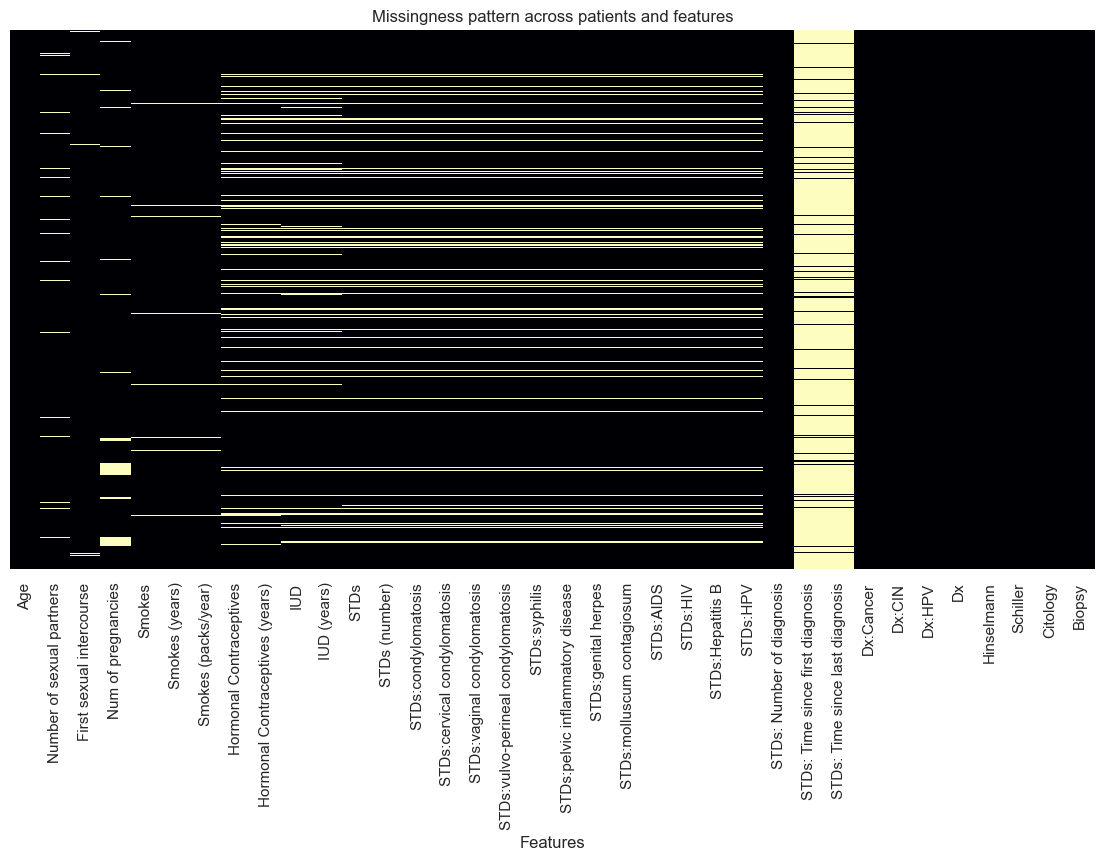

In [14]:
# Original missingness heatmap, now applied after explicit cleaning.
plt.figure(figsize=(14, 7))
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Missingness pattern across patients and features')
plt.xlabel('Features')
plt.show()

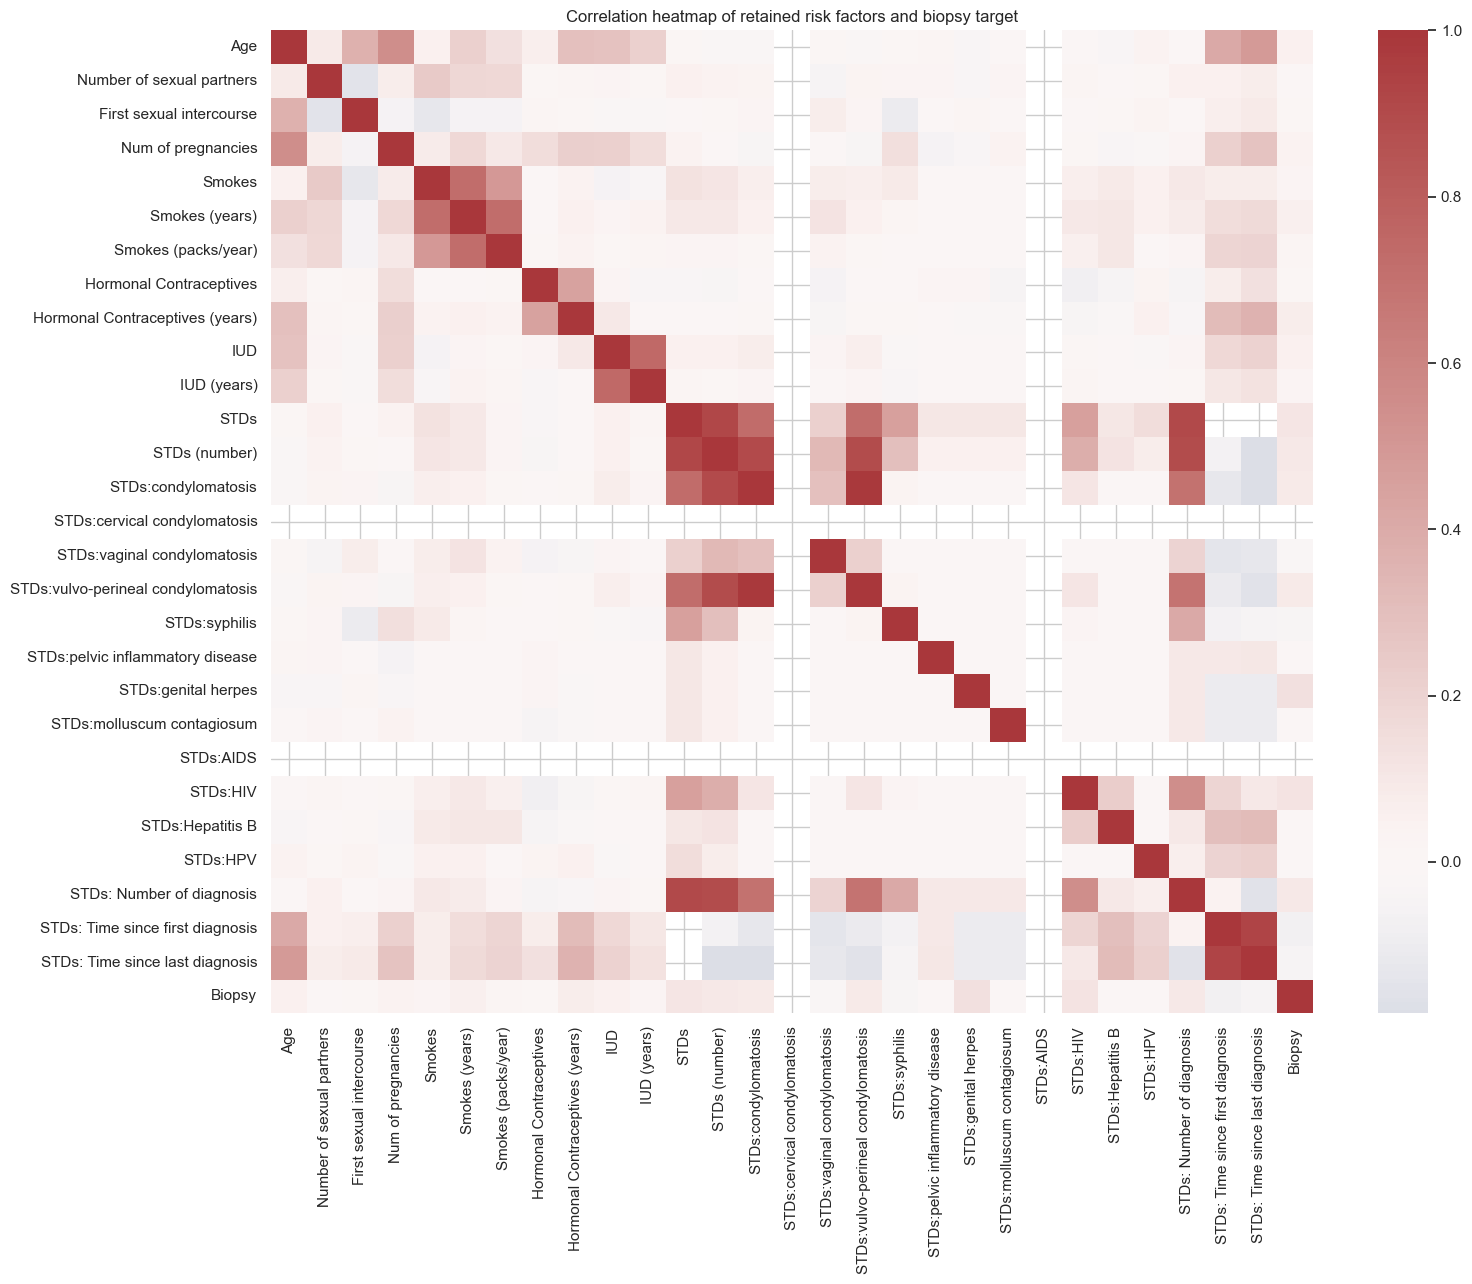

In [15]:
# Original correlation view, excluding diagnostic leakage columns.
plt.figure(figsize=(16, 13))
correlation_view = data[risk_features + [TARGET]].corr()
sns.heatmap(correlation_view, cmap='vlag', center=0, square=False)
plt.title('Correlation heatmap of retained risk factors and biopsy target')
plt.tight_layout()
plt.show()

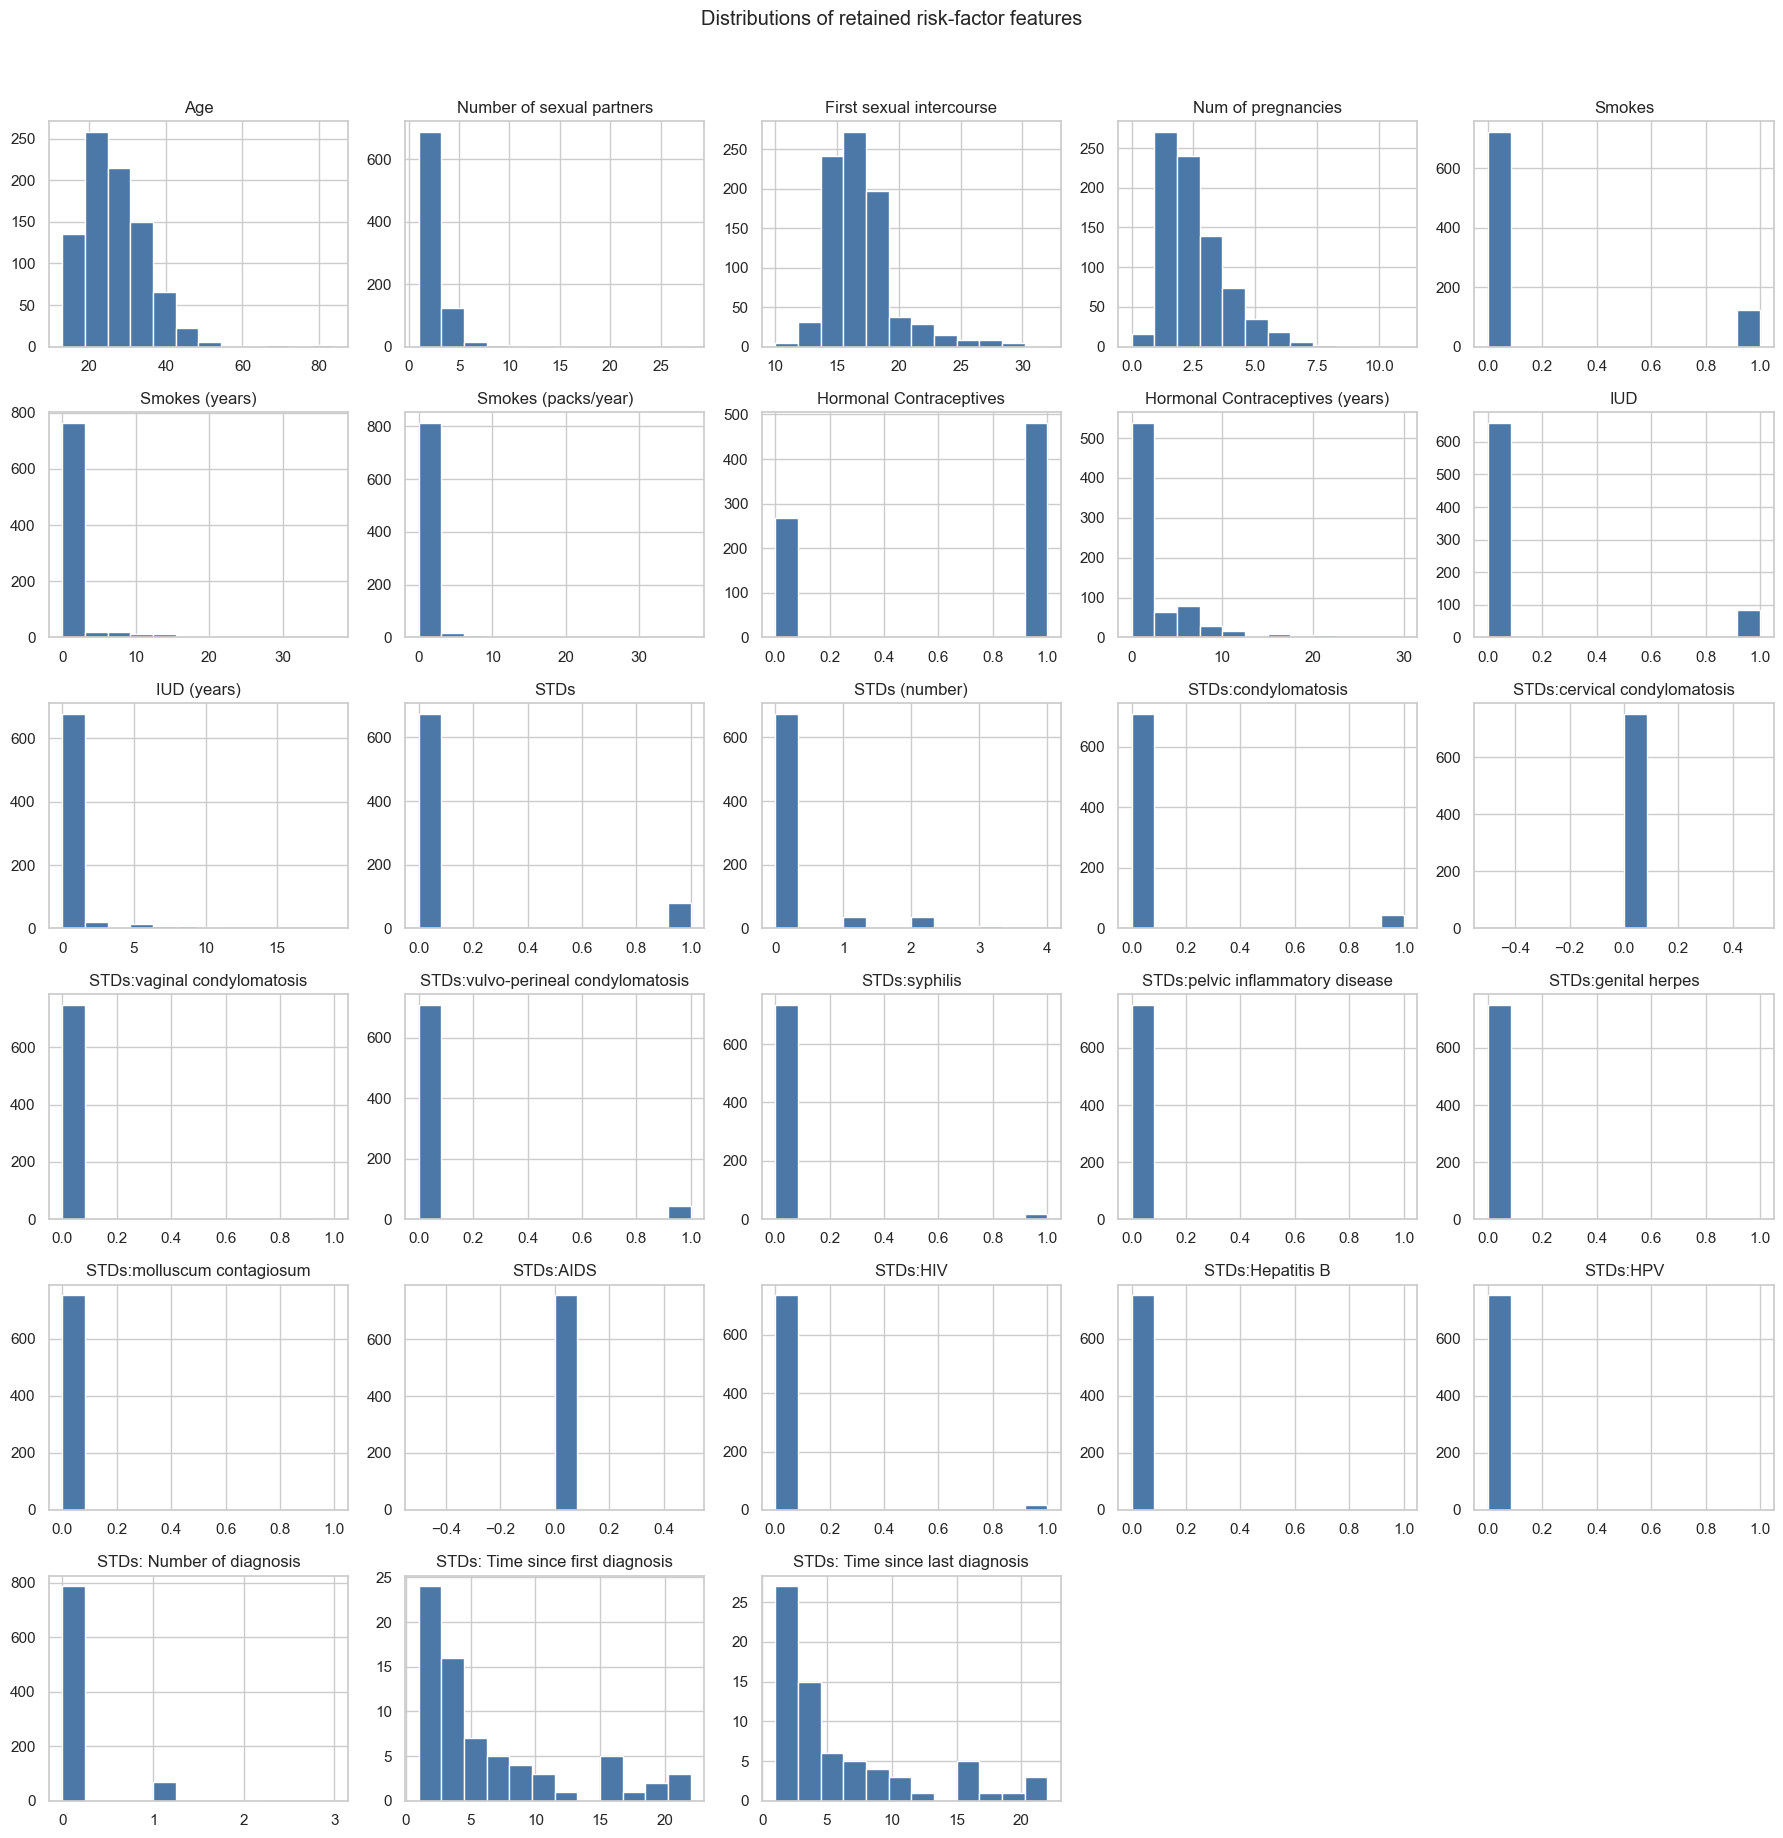

In [16]:
# Original distribution overview, limited to retained features for readability.
data[risk_features].hist(bins=12, figsize=(18, 18), color='#4C78A8')
plt.suptitle('Distributions of retained risk-factor features', y=1.02)
plt.tight_layout()
plt.show()

# Model development and honest evaluation

The next section reuses the cleaned EDA data. Its preprocessing, cross-validation, and final evaluation remain isolated from the holdout test data.

## 1. Imports, reproducibility, and paths

A fixed random seed makes the split and model repeatable. Pipelines are used so
preprocessing is learned from training data only, preventing information from the
test set from leaking into imputation or scaling.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data" / "cervical_cancer.csv").exists():
    PROJECT_DIR = PROJECT_DIR / "001_Cervical_Cancer_Predection_with_ML"

DATA_PATH = PROJECT_DIR / "data" / "cervical_cancer.csv"
ASSET_DIR = PROJECT_DIR / "docs" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

## Create the leakage-safe feature matrix

The EDA section has already loaded and cleaned `data`. We now form the predictors and binary target without re-reading the CSV.

In [18]:
X = data.drop(columns=[TARGET, *LEAKAGE_COLUMNS])
y = data[TARGET].astype(int)

assert not y.isna().any(), 'Target labels cannot be missing.'
assert set(y.unique()) == {0, 1}, 'This workflow expects a binary target.'

print(f'Features retained: {X.shape[1]}')
print(f'Positive class: {y.sum()} of {len(y)} ({y.mean():.2%})')

Features retained: 28
Positive class: 55 of 858 (6.41%)


## 3. Create a stratified holdout set

The holdout set is used only once for final comparison. `stratify=y` preserves the
rare positive-class proportion in both partitions. Without stratification, a small
test set could contain too few positive cases for a meaningful evaluation.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "positive_cases": [int(y_train.sum()), int(y_test.sum())],
        "positive_rate": [y_train.mean(), y_test.mean()],
    },
    index=["Training", "Test"],
)
split_summary

,rows,positive_cases,positive_rate
Training,686,44,0.064140
Test,172,11,0.063953


## 4. Define leakage-safe preprocessing

Median imputation is robust to skewed numerical features. Logistic regression also
needs scaling because its optimization and coefficients are sensitive to feature
units. The random forest does not require scaling, so it receives imputed values
only. Crucially, each transformer is fitted inside its pipeline during training.

In [20]:
numeric_features = X.columns.tolist()

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ],
    remainder="drop",
)

## 5. Define two complementary models

Logistic regression is the transparent baseline: it is fast, stable, and easy to
interpret. Random forest captures nonlinear relationships and feature interactions.
Both use balanced class weights so errors on the rare positive class receive more
attention than they would under ordinary accuracy optimization.

In [21]:
models = {
    "Logistic regression": Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=2_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random forest": Pipeline(
        steps=[
            ("preprocess", tree_preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=3,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

## 6. Cross-validation on training data

Five-fold stratified cross-validation measures how stable each model is across
different training subsets without touching the holdout set. PR-AUC is especially
informative for rare positive outcomes; ROC-AUC measures ranking across thresholds;
recall measures how many positive cases are found.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
}

cv_rows = []
for name, pipeline in models.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).set_index("model")
cv_results.round(3)

,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
model,,,,,,,,,,
Logistic regression,0.573,0.074,0.133,0.030,0.431,0.103,0.111,0.023,0.176,0.035
Random forest,0.622,0.045,0.161,0.058,0.044,0.089,0.067,0.133,0.053,0.107


## 7. Fit models and evaluate the untouched test set

The default probability threshold is 0.5. We report several metrics because each
answers a different question. In a screening context, recall often matters greatly,
but false positives also have real consequences; threshold selection must therefore
be made with clinical and operational stakeholders, not from this notebook alone.

In [23]:
test_rows = []
predictions = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    probability = pipeline.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    predictions[name] = {"probability": probability, "prediction": prediction}
    test_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, prediction),
            "precision": precision_score(y_test, prediction, zero_division=0),
            "recall": recall_score(y_test, prediction, zero_division=0),
            "f1": f1_score(y_test, prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probability),
            "pr_auc": average_precision_score(y_test, probability),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("model")
test_results.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic regression,0.738,0.095,0.364,0.151,0.578,0.092
Random forest,0.924,0.250,0.091,0.133,0.685,0.185


## 8. Confusion matrices

A confusion matrix exposes the actual error counts hidden by summary metrics.
False negatives are positive biopsies the model misses; false positives are people
flagged by the model whose biopsy is negative.

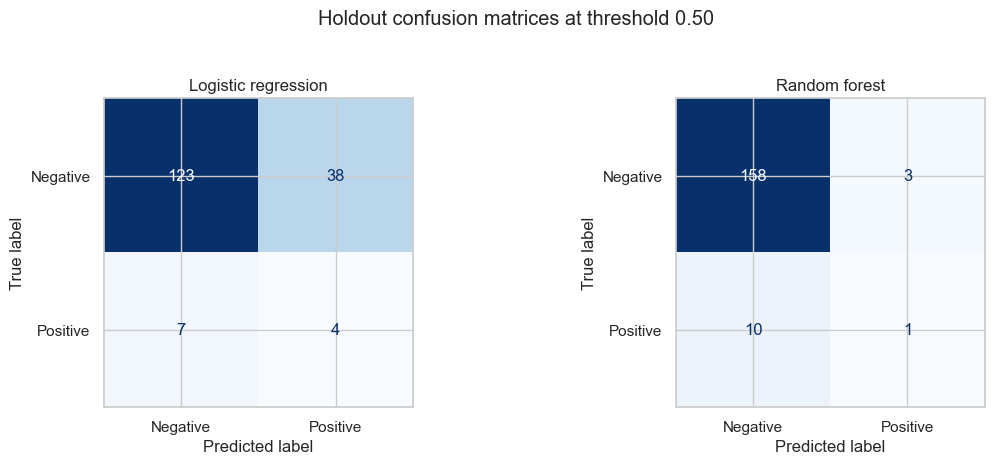

In [24]:
fig, axes = plt.subplots(1, len(models), figsize=(12, 4.5))
for ax, (name, values) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        values["prediction"],
        display_labels=["Negative", "Positive"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
fig.suptitle("Holdout confusion matrices at threshold 0.50", y=1.03)
fig.tight_layout()
fig.savefig(ASSET_DIR / "confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. ROC and precision–recall curves

Curves show model behavior across every threshold instead of locking evaluation to
0.5. The precision–recall curve is particularly useful here because the positive
class is rare and it directly displays the trade-off between finding positives and
limiting false alarms.

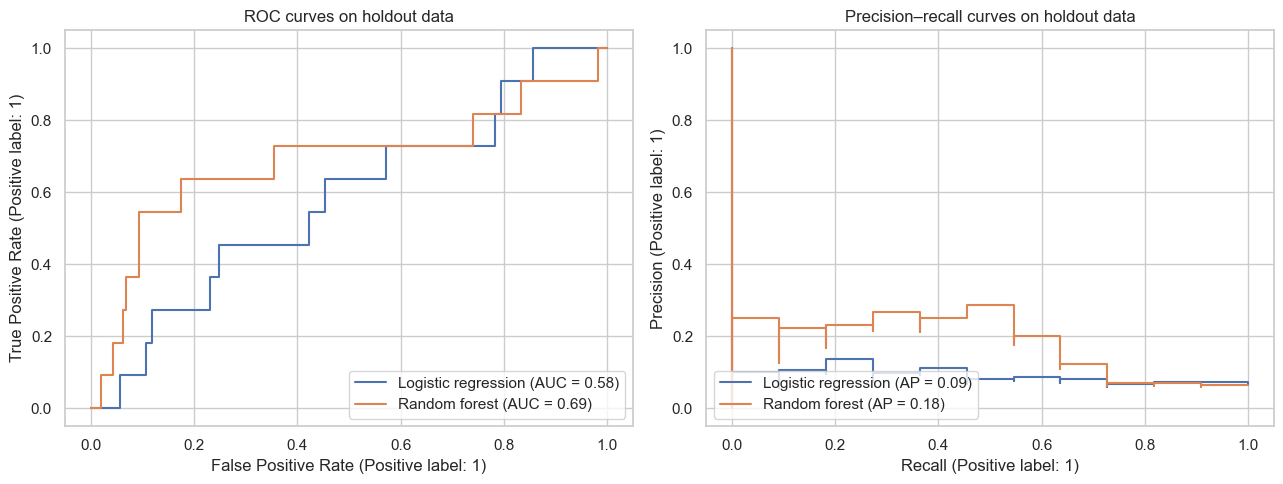

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, values in predictions.items():
    RocCurveDisplay.from_predictions(y_test, values["probability"], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, values["probability"], name=name, ax=axes[1])
axes[0].set_title("ROC curves on holdout data")
axes[1].set_title("Precision–recall curves on holdout data")
fig.tight_layout()
fig.savefig(ASSET_DIR / "evaluation_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Detailed classification reports

Per-class results prevent the majority negative class from dominating the story.
Support is the number of true examples in each class and should always be read
alongside precision and recall.

In [26]:
for name, values in predictions.items():
    print(f"\n{name}\n{'-' * len(name)}")
    print(classification_report(y_test, values["prediction"], target_names=["Negative", "Positive"], zero_division=0))


Logistic regression
-------------------
              precision    recall  f1-score   support

    Negative       0.95      0.76      0.85       161
    Positive       0.10      0.36      0.15        11

    accuracy                           0.74       172
   macro avg       0.52      0.56      0.50       172
weighted avg       0.89      0.74      0.80       172


Random forest
-------------
              precision    recall  f1-score   support

    Negative       0.94      0.98      0.96       161
    Positive       0.25      0.09      0.13        11

    accuracy                           0.92       172
   macro avg       0.60      0.54      0.55       172
weighted avg       0.90      0.92      0.91       172



## 11. Model interpretation with permutation importance

Permutation importance measures how much ROC-AUC falls when one feature is shuffled
in the holdout data. It works consistently across both model types and reflects
predictive reliance rather than claiming causality. With a small positive class,
the ranking is exploratory and should be validated on external data.

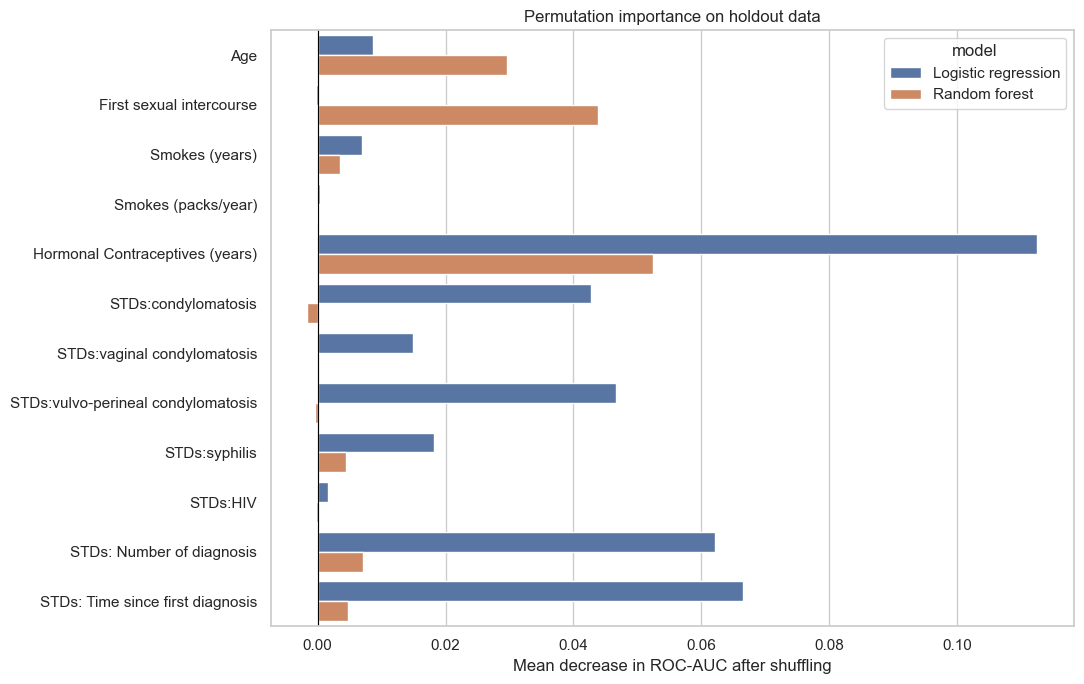

In [27]:
importance_rows = []
for name, pipeline in models.items():
    result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    for feature, mean, std in zip(X.columns, result.importances_mean, result.importances_std):
        importance_rows.append({"model": name, "feature": feature, "importance": mean, "std": std})

importance = pd.DataFrame(importance_rows)
top_features = (
    importance.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
    .index
)
plot_data = importance[importance["feature"].isin(top_features)].copy()

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=plot_data, x="importance", y="feature", hue="model", errorbar=None, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Permutation importance on holdout data", xlabel="Mean decrease in ROC-AUC after shuffling", ylabel="")
fig.tight_layout()
fig.savefig(ASSET_DIR / "permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Interpretation, limitations, and next steps

- The dataset is small and the positive biopsy class is rare, so estimates have
  substantial uncertainty.
- Missing values are imputed; missingness itself may contain patterns that deserve
  further investigation.
- The analysis avoids obvious diagnostic leakage, but temporal ordering should be
  confirmed with domain experts.
- Performance from one hospital and one holdout split does not establish external
  validity, fairness, calibration, or clinical usefulness.
- A production study would require external cohorts, calibration analysis,
  subgroup evaluation, threshold selection, privacy review, and clinical oversight.

The appropriate “best model” depends on the cost of missed cases versus false
alerts. The metrics above support that decision; they do not make it automatically.

In [28]:
comparison = test_results.sort_values(["recall", "pr_auc"], ascending=False)
print("Models ranked by recall, then PR-AUC:")
display(comparison.round(3))

Models ranked by recall, then PR-AUC:


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic regression,0.738,0.095,0.364,0.151,0.578,0.092
Random forest,0.924,0.250,0.091,0.133,0.685,0.185


## Retained XGBoost comparison, rebuilt safely

The original project used XGBoost. This version retains that model with the same leakage boundary, training-only imputation, class imbalance handling, and holdout metrics as the other models. Its parameters are intentionally moderate to reduce overfitting on this small dataset.

In [29]:
from xgboost import XGBClassifier

# Weight positive cases by the training-set imbalance ratio.
positive_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgboost_pipeline = Pipeline(
    steps=[
        ('preprocess', tree_preprocessor),
        ('model', XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=positive_weight, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]
)

xgboost_pipeline.fit(X_train, y_train)
xgb_probability = xgboost_pipeline.predict_proba(X_test)[:, 1]
xgb_prediction = (xgb_probability >= 0.5).astype(int)

xgb_results = pd.DataFrame([{
    'accuracy': accuracy_score(y_test, xgb_prediction),
    'precision': precision_score(y_test, xgb_prediction, zero_division=0),
    'recall': recall_score(y_test, xgb_prediction, zero_division=0),
    'f1': f1_score(y_test, xgb_prediction, zero_division=0),
    'roc_auc': roc_auc_score(y_test, xgb_probability),
    'pr_auc': average_precision_score(y_test, xgb_probability),
}], index=['XGBoost'])
display(xgb_results.round(3))

,accuracy,precision,recall,f1,roc_auc,pr_auc
XGBoost,0.797,0.125,0.364,0.186,0.66,0.219


### Final interpretation

Compare models using the full metric table rather than selecting the highest accuracy. With only 11 positive cases in the holdout data, results have considerable uncertainty. The notebook demonstrates a careful experiment; it does not establish clinical usefulness.